# Projeto de Previsão de Preço de Imóveis

### Desenvolvimento de IA para Análise Preditiva

**Projeto Avaliativo – Módulo 1**

**Dataset:** kc_house_data.csv

**Aluno(a):** Samira Salema

# Contextualização

Neste projeto será desenvolvido um modelo de Machine Learning para prever o preço de venda de imóveis no condado de King County, Estados Unidos.

A variável-alvo do modelo é **price**, que representa o valor de venda de um imóvel em dólares.

Essa previsão é importante para o mercado imobiliário, pois pode auxiliar imobiliárias, compradores, vendedores e instituições financeiras a estimarem o valor de um imóvel de forma mais rápida e baseada em dados.

# Importação das Bibliotecas

In [40]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Divisão dos dados
from sklearn.model_selection import train_test_split

# Padronização dos dados
from sklearn.preprocessing import StandardScaler

# Modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# Métricas de avaliação
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Salvamento do modelo
import joblib

# Manipulação de arquivos JSON
import json

# Data e hora
from datetime import datetime

# Carregamento do Dataset


In [41]:
df = pd.read_csv("kc_house_data.csv")

In [42]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [43]:
df.shape

(21613, 21)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Fase 1 - Análise Exploratória dos Dados (EDA)

## Estatística Descritiva

A distribuição da variável price apresenta assimetria positiva, indicando imóveis de alto valor que podem influenciar a regressão. A matriz de correlação mostra forte relação entre sqft_living e price. Essas informações orientarão a seleção das variáveis do modelo."

In [45]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


### Análise inicial da estatística descritiva

A análise estatística inicial permite compreender o comportamento das variáveis numéricas do dataset.

A variável **price**, que representa o valor dos imóveis, apresenta grande variação entre os registros, indicando a existência de imóveis com valores muito diferentes dentro da base.

A diferença entre a média e a mediana sugere uma possível assimetria na distribuição dos preços, indicando a necessidade de investigar a presença de valores extremos (outliers) durante as próximas etapas da análise exploratória.

As variáveis relacionadas ao tamanho do imóvel, como **sqft_living**, também apresentam grande variação, o que pode influenciar diretamente o preço final do imóvel.


## Distribuição da Variável Alvo - Price

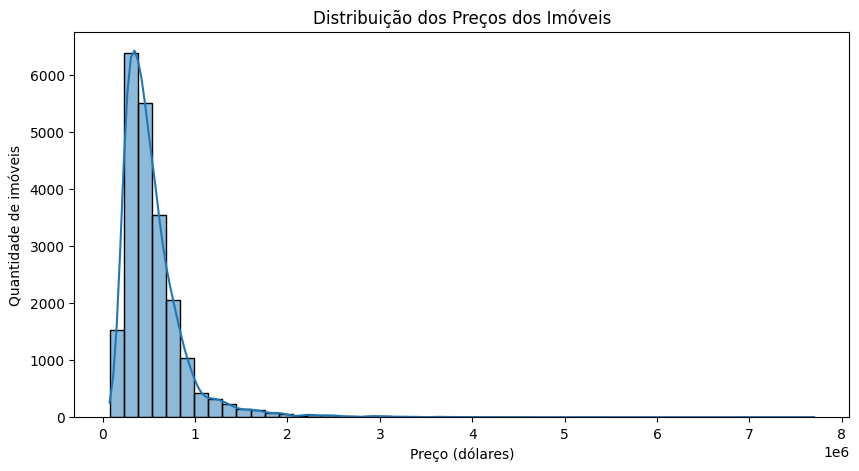

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Distribuição dos Preços dos Imóveis")
plt.xlabel("Preço (dólares)")
plt.ylabel("Quantidade de imóveis")

plt.show()

### Interpretação do Histograma

O histograma da variável **price** demonstra que a distribuição dos preços dos imóveis apresenta maior concentração nos valores mais baixos e intermediários.

Observa-se uma assimetria na distribuição, com poucos imóveis apresentando valores extremamente elevados. Esses valores podem representar imóveis de alto padrão e também possíveis outliers, que deverão ser avaliados durante a etapa de tratamento dos dados.

Esse comportamento indica que a variável alvo possui grande variabilidade, característica que deve ser considerada durante a construção do modelo preditivo.

## Relação entre Área Construída e Preço do Imóvel

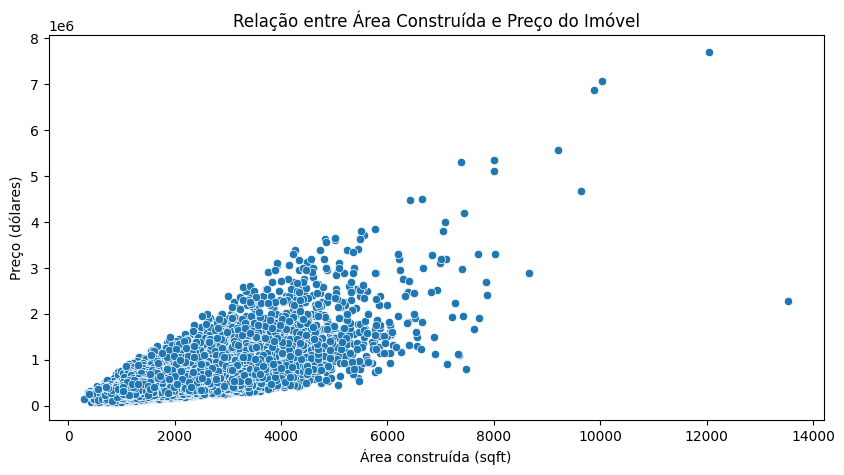

In [47]:
# Gráfico de dispersão entre área construída e preço

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price"
)

plt.title("Relação entre Área Construída e Preço do Imóvel")
plt.xlabel("Área construída (sqft)")
plt.ylabel("Preço (dólares)")

plt.show()

### Interpretação do Gráfico de Dispersão

O gráfico de dispersão entre **sqft_living** (área construída) e **price** demonstra uma tendência positiva entre as variáveis.

Observa-se que, de forma geral, imóveis com maior área construída apresentam preços mais elevados, indicando que o tamanho do imóvel possui influência sobre o valor de venda.

Também são observados alguns pontos extremos, representando imóveis com valores muito superiores aos demais registros. Esses casos podem estar relacionados a características específicas, como localização privilegiada, maior qualidade de construção ou outros fatores que influenciam o preço.

Esses valores serão analisados posteriormente durante a etapa de tratamento de outliers.

Matriz de Correlação das Variáveis Numéricas

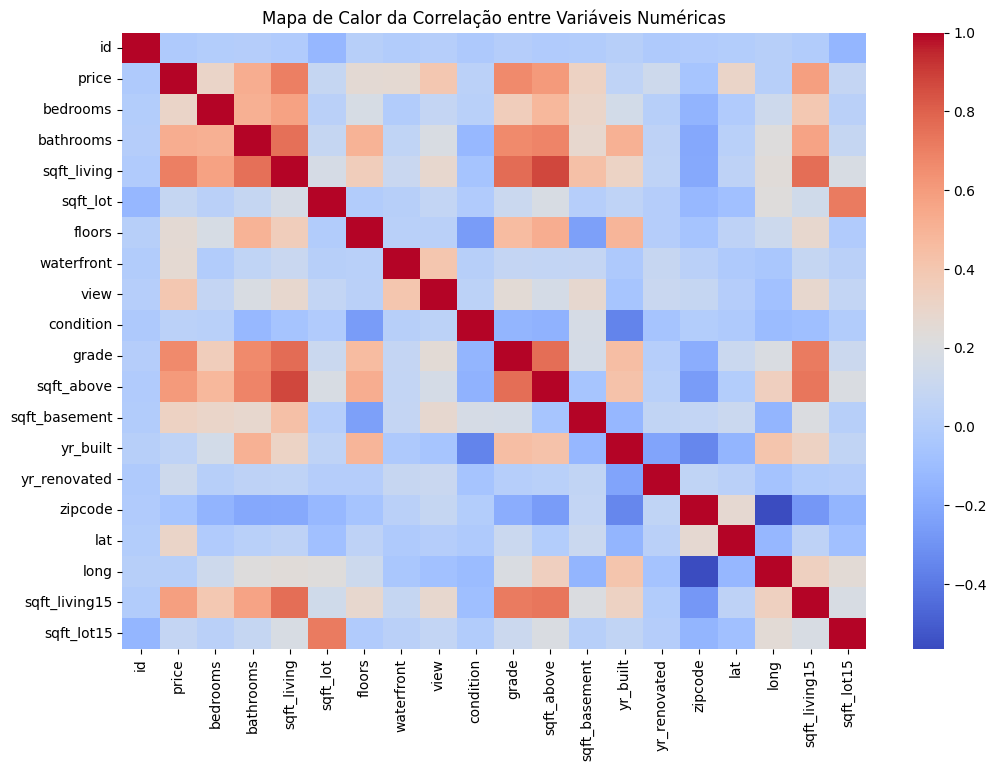

In [48]:
# Matriz de correlação das variáveis numéricas

plt.figure(figsize=(12,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Mapa de Calor da Correlação entre Variáveis Numéricas")

plt.show()

### Interpretação da Matriz de Correlação

A matriz de correlação permite identificar o relacionamento entre as variáveis numéricas do dataset.

Observa-se que a variável **price** apresenta maior correlação positiva com características relacionadas ao tamanho e qualidade do imóvel, especialmente **sqft_living** (área construída).

Esse resultado indica que imóveis maiores tendem a apresentar valores de venda mais elevados.

A análise de correlação será utilizada como apoio na escolha das variáveis preditoras do modelo e também para investigar possíveis problemas de multicolinearidade entre as variáveis explicativas.

# Fase 2 - Tratamento e Limpeza dos Dados (Data Prep)

## Análise de Registros Duplicados

In [49]:
df.duplicated().sum()

np.int64(0)

### Análise de Registros Duplicados

Foi realizada a verificação de registros duplicados utilizando o método `duplicated()`.

O resultado identificou **0 registros duplicados** no dataset.

Dessa forma, não foi necessária a remoção de linhas, pois não existem registros idênticos que possam causar redundância ou distorção na análise dos dados.

# Análise de Valores Ausentes (Missing Data)

In [50]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


## Tratamento de Valores Ausentes


In [51]:
# Substituir valores ausentes da coluna sqft_above pela mediana

df["sqft_above"] = df["sqft_above"].fillna(
    df["sqft_above"].median()
)

### Justificativa da Imputação

Foram identificados 2 valores ausentes na variável **sqft_above**.

Como essa variável representa uma medida de área e pode apresentar valores extremos devido à existência de imóveis de diferentes padrões, optou-se pela substituição dos valores ausentes pela **mediana**.

A mediana foi escolhida por ser menos sensível a outliers quando comparada à média, preservando melhor o comportamento da distribuição original dos dados.

## Análise de Outliers

### Boxplot da Variável Price

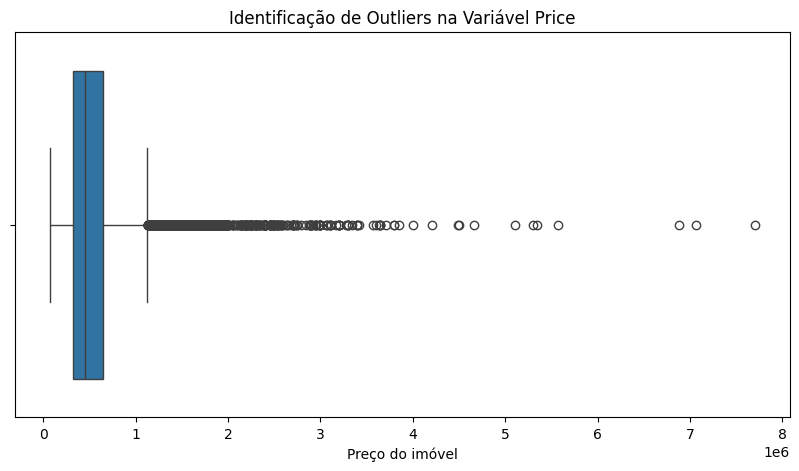

In [52]:
# Boxplot para identificar valores extremos na variável price

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["price"]
)

plt.title("Identificação de Outliers na Variável Price")
plt.xlabel("Preço do imóvel")

plt.show()

### Análise e Tratamento de Outliers

Foi realizada a análise de valores extremos utilizando o gráfico de boxplot da variável **price**.

Foram identificados alguns valores acima do limite superior da distribuição, porém esses registros não foram removidos.

A decisão de manter os valores extremos foi tomada considerando que imóveis com preços elevados podem representar situações reais do mercado imobiliário, como propriedades de alto padrão.

A remoção desses registros poderia eliminar informações relevantes e reduzir a capacidade do modelo de aprender diferentes faixas de preço.

Entretanto, esses valores serão considerados durante a modelagem, pois modelos de regressão linear podem ser sensíveis a valores extremos.

# Fase 3 - Feature Engineering

## Criação da Coluna Idade do Imóvel

In [53]:
# Converter a coluna date para formato de data

df["date"] = pd.to_datetime(df["date"])

# Criar uma coluna com o ano da venda

df["yr_sale"] = df["date"].dt.year

# Visualizar as primeiras linhas

df[["date", "yr_sale"]].head()

,date,yr_sale
0,2014-10-13,2014
1,2014-12-09,2014
2,2015-02-25,2015
3,2014-12-09,2014
4,2015-02-18,2015


In [54]:
# Criar a variável idade do imóvel

df["idade_imovel"] = df["yr_sale"] - df["yr_built"]

# Visualizar o resultado

df[["yr_sale", "yr_built", "idade_imovel"]].head()

,yr_sale,yr_built,idade_imovel
0,2014,1955,59
1,2014,1951,63
2,2015,1933,82
3,2014,1965,49
4,2015,1987,28


In [55]:
(df["idade_imovel"] < 0).sum()

np.int64(12)

### Justificativa da Nova Variável

Foi criada a variável **idade_imovel**, calculada pela diferença entre o ano de venda do imóvel e o ano de construção.

Essa característica pode contribuir para o modelo preditivo, pois a idade do imóvel pode influenciar seu valor de mercado.

A criação dessa variável permite incorporar uma informação derivada que não estava disponível diretamente no dataset original.

In [56]:
# Visualizar imóveis com idade negativa

df[df["idade_imovel"] < 0][
    ["date", "yr_sale", "yr_built", "idade_imovel"]
]

,date,yr_sale,yr_built,idade_imovel
1763,2014-06-25,2014,2015,-1
2687,2014-10-29,2014,2015,-1
7526,2014-12-31,2014,2015,-1
8039,2014-06-24,2014,2015,-1
14489,2014-08-26,2014,2015,-1
17098,2014-06-17,2014,2015,-1
19805,2014-08-01,2014,2015,-1
20770,2014-08-28,2014,2015,-1
20852,2014-07-09,2014,2015,-1
20963,2014-07-31,2014,2015,-1


### Validação da Variável idade_imovel

Após a criação da variável **idade_imovel**, foram identificados 12 registros com idade igual a -1.

Ao investigar esses casos, verificou-se que todos correspondem a imóveis vendidos em 2014 e cadastrados com ano de construção de 2015.

Esses registros podem representar imóveis novos vendidos ainda em fase de construção ou na planta. Como representam uma parcela muito pequena do dataset e não há evidências de erro de cadastro, optou-se por manter esses registros, preservando a integridade dos dados originais.

# Fase 4 - Preparação para Modelagem

### Avaliação da Multicolinearidade

Antes da etapa de modelagem, foi analisada a matriz de correlação entre as variáveis numéricas para verificar possíveis problemas de multicolinearidade.

Observou-se que algumas variáveis apresentam correlação relativamente elevada, principalmente aquelas relacionadas ao tamanho do imóvel, como `sqft_living`, `sqft_above` e `sqft_living15`. Entretanto, nesta primeira versão do modelo optou-se por manter todas as variáveis preditoras, pois elas representam características importantes dos imóveis e contribuem para a capacidade explicativa da Regressão Linear.

Como a matriz de correlação não indicou necessidade evidente de exclusão de variáveis nesta etapa, nenhuma variável foi removida.

Em versões futuras do projeto poderá ser aplicada uma análise utilizando o VIF (Variance Inflation Factor) para identificar e remover automaticamente variáveis com alta multicolinearidade, buscando simplificar o modelo sem perda significativa de desempenho.

Além disso, a variável zipcode foi mantida utilizando sua representação numérica original. Embora se trate de uma variável categórica nominal e técnicas como One-Hot Encoding possam representar melhor essa característica, optou-se por mantê-la nesta primeira versão do modelo para preservar a simplicidade da Regressão Linear e facilitar a interpretação dos resultados. Em versões futuras poderá ser avaliado o uso de técnicas de codificação para verificar possíveis ganhos de desempenho.

In [57]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'yr_sale',
       'idade_imovel'],
      dtype='object')

## Separação das Variáveis Preditoras e Variável Alvo

A variável alvo do modelo será **price**, pois o objetivo é prever o valor de venda dos imóveis.

As demais características serão utilizadas como variáveis explicativas (preditoras).

In [58]:
# Definir as variáveis preditoras

X = df.drop(columns=["price", "id", "date"])

# Definir a variável alvo

y = df["price"]

# Visualizar as dimensões

print("Dimensão das variáveis preditoras:", X.shape)
print("Dimensão da variável alvo:", y.shape)

Dimensão das variáveis preditoras: (21613, 20)
Dimensão da variável alvo: (21613,)


## Divisão dos Dados em Treino e Teste

O dataset será dividido em dados de treinamento e dados de teste utilizando a proporção de 80% para treinamento e 20% para avaliação do modelo.

Essa divisão permite avaliar a capacidade de generalização do modelo para novos dados.

In [59]:
# Divisão dos dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Verificar dimensões

print("X treino:", X_train.shape)
print("X teste:", X_test.shape)
print("y treino:", y_train.shape)
print("y teste:", y_test.shape)

X treino: (17290, 20)
X teste: (4323, 20)
y treino: (17290,)
y teste: (4323,)


Escalonamento dos Dados (StandardScaler)

## Padronização das Variáveis com StandardScaler

Foi aplicada a padronização das variáveis preditoras utilizando o StandardScaler.

O ajuste foi realizado somente com os dados de treinamento e posteriormente aplicado aos dados de teste, evitando vazamento de informações.

In [60]:
# Criar o objeto StandardScaler

scaler = StandardScaler()

# Ajustar e transformar os dados de treino

X_train_scaled = scaler.fit_transform(X_train)

# Transformar os dados de teste usando o mesmo padrão

X_test_scaled = scaler.transform(X_test)

# Verificar dimensões após o escalonamento

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (17290, 20)
X_test_scaled: (4323, 20)


# Fase 5 - Modelagem, Validação e Diagnóstico de Overfitting

## Modelo Base - Regressão Linear

In [61]:
# Criar o modelo de Regressão Linear

modelo_lr = LinearRegression()

In [62]:
# Treinar o modelo utilizando os dados de treino

modelo_lr.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

## Geração de Previsões

Após o treinamento do modelo, serão geradas previsões utilizando os dados de teste, que representam imóveis não utilizados durante o aprendizado.

In [63]:
# Gerar previsões utilizando os dados de teste

y_pred = modelo_lr.predict(X_test_scaled)

# Visualizar as primeiras previsões

y_pred[:10]

array([ 452162.65744784,  744754.3273998 , 1228754.3073829 ,
       1683825.23232   ,  725614.54739582,  271580.9356852 ,
        823739.2008292 ,  492413.72985388,  374453.12168285,
        470032.58864665])

## Diagnóstico de Overfitting

A comparação entre o desempenho nos dados de treino e teste permite avaliar a capacidade de generalização do modelo.

In [64]:
# Previsões no conjunto de treino

y_train_pred = modelo_lr.predict(X_train_scaled)

# Calcular R² no treino e teste

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

# Criar tabela comparativa

comparacao = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "R²": [r2_train, r2_test]
})

comparacao

,Conjunto,R²
0,Treino,0.700649
1,Teste,0.702567


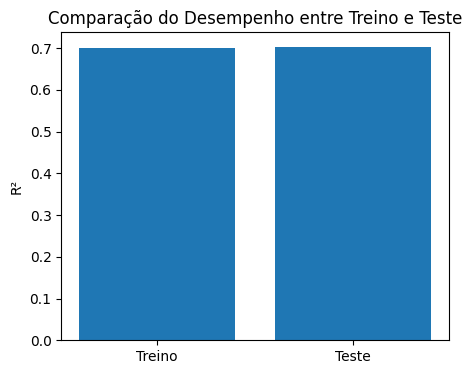

In [65]:
plt.figure(figsize=(5,4))

plt.bar(
    comparacao["Conjunto"],
    comparacao["R²"]
)

plt.ylabel("R²")
plt.title("Comparação do Desempenho entre Treino e Teste")

plt.show()

### Análise de Overfitting

A tabela e o gráfico demonstram que os valores de R² obtidos nos conjuntos de treinamento e teste são muito próximos, indicando que o modelo apresenta desempenho consistente tanto durante o treinamento quanto na avaliação com dados não utilizados anteriormente.

O conjunto de treinamento apresentou R² de aproximadamente 0,70, enquanto o conjunto de teste apresentou desempenho semelhante, também próximo de 0,70.

Essa proximidade indica que não há sinais relevantes de overfitting, sugerindo que o modelo possui boa capacidade de generalização para novos dados.

Embora existam oportunidades de melhoria por meio da seleção de variáveis, engenharia de atributos ou utilização de modelos mais robustos, a primeira versão da Regressão Linear apresentou comportamento estável e adequado para o problema proposto.

# Fase 6 - Avaliação, Interpretação e Versionamento do Modelo

## Métricas de Avaliação do Modelo

In [66]:
# Cálculo das métricas de avaliação

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# Exibir resultados

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 126904.31
MSE: 44964934559.27
RMSE: 212049.37
R²: 0.7026


## Interpretação de Negócio

O modelo desenvolvido apresentou um R² de aproximadamente 0,70, indicando que cerca de 70% da variação dos preços dos imóveis consegue ser explicada pelas características utilizadas no modelo.

O MAE obtido foi de aproximadamente US$ 126.904, indicando que, em média, as previsões apresentam um erro próximo desse valor.

Para uma aplicação imobiliária, essa margem de erro pode ser considerada relevante, principalmente em decisões financeiras de alto valor, como compra, venda ou financiamento de imóveis.

A primeira versão do modelo demonstra capacidade preditiva, porém melhorias podem ser realizadas em versões futuras, como testar outros algoritmos de regressão, realizar ajustes de hiperparâmetros e aprimorar o tratamento de variáveis com maior influência no preço.

## Comparação entre Valores Reais e Valores Previstos

O gráfico abaixo compara os valores reais dos imóveis com os valores previstos pelo modelo de Regressão Linear.

A linha de referência representa uma previsão perfeita, onde o valor previsto seria exatamente igual ao valor real.

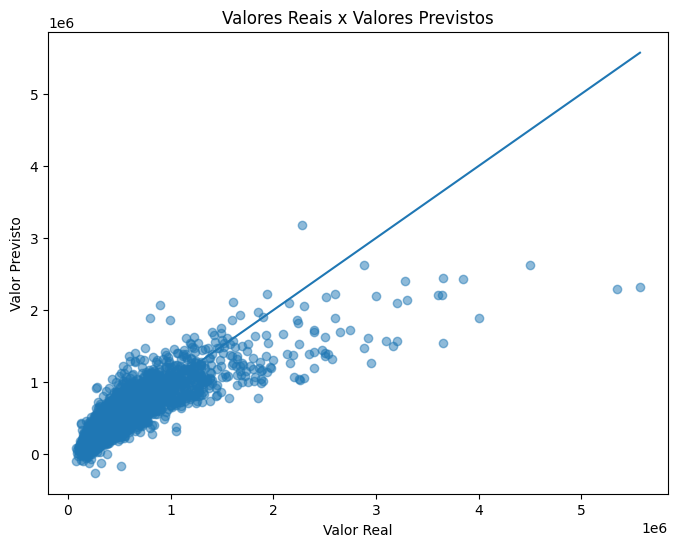

In [67]:
# Gráfico de valores reais versus valores previstos

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Linha de previsão perfeita

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais x Valores Previstos")

plt.show()

### Análise do Gráfico Real x Previsto

O gráfico de dispersão entre os valores reais e previstos demonstra uma tendência linear positiva, indicando que o modelo consegue acompanhar o comportamento geral dos preços dos imóveis.

Observa-se que grande parte dos pontos está próxima da linha de referência, indicando previsões coerentes.

Entretanto, existe maior dispersão nos imóveis de valores mais elevados, indicando que o modelo apresenta maior dificuldade em estimar preços extremos. Esse comportamento está relacionado à sensibilidade da Regressão Linear a valores fora do padrão da distribuição.

## Análise dos Resíduos

Os resíduos representam a diferença entre os valores reais e os valores previstos pelo modelo.

A análise da distribuição dos resíduos permite verificar se os erros estão concentrados próximos de zero e se existe algum padrão sistemático nas previsões.

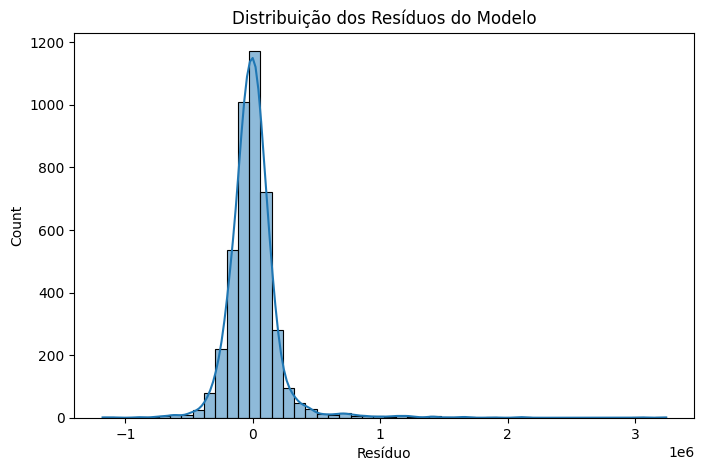

In [68]:
# Cálculo dos resíduos

residuos = y_test - y_pred

# Histograma da distribuição dos resíduos

plt.figure(figsize=(8,5))

sns.histplot(
    residuos,
    bins=50,
    kde=True
)

plt.xlabel("Resíduo")
plt.title("Distribuição dos Resíduos do Modelo")

plt.show()

### Análise da Distribuição dos Resíduos

A análise da distribuição dos resíduos mostrou que os erros estão concentrados próximos de zero, indicando que o modelo apresenta previsões razoavelmente próximas dos valores reais para grande parte dos imóveis.

Entretanto, a distribuição dos resíduos não apresenta simetria perfeita, sugerindo a presença de alguns erros maiores em determinadas previsões.

Esse comportamento pode estar relacionado aos imóveis de valores mais elevados, que apresentam maior variabilidade e são mais difíceis de estimar utilizando um modelo de Regressão Linear.

In [69]:
# Criar estrutura de pastas para salvar o modelo

import os

os.makedirs("models/v1", exist_ok=True)

print("Pasta models/v1 criada com sucesso!")

Pasta models/v1 criada com sucesso!


In [70]:
# Importar biblioteca para salvar modelos

import joblib

# Salvar o modelo treinado

joblib.dump(
    modelo_lr,
    "models/v1/modelo_regressao_v1.pkl"
)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


In [71]:
from datetime import datetime
import json

In [72]:
# Criar dicionário com as informações do modelo

metricas_v1 = {
    "modelo": "Regressao Linear",
    "versao": "v1",
    "data_treinamento": datetime.now().strftime("%Y-%m-%d"),
    "MAE": float(mae),
    "MSE": float(mse),
    "RMSE": float(rmse),
    "R2": float(r2),
    "variaveis_preditoras": list(X.columns)
}

metricas_v1

{'modelo': 'Regressao Linear',
 'versao': 'v1',
 'data_treinamento': '2026-07-17',
 'MAE': 126904.30753412863,
 'MSE': 44964934559.26891,
 'RMSE': 212049.36821237858,
 'R2': 0.7025670562085561,
 'variaveis_preditoras': ['bedrooms',
  'bathrooms',
  'sqft_living',
  'sqft_lot',
  'floors',
  'waterfront',
  'view',
  'condition',
  'grade',
  'sqft_above',
  'sqft_basement',
  'yr_built',
  'yr_renovated',
  'zipcode',
  'lat',
  'long',
  'sqft_living15',
  'sqft_lot15',
  'yr_sale',
  'idade_imovel']}

In [73]:
# Salvar métricas em arquivo JSON

with open(
    "models/v1/metricas_v1.json",
    "w",
    encoding="utf-8"
) as arquivo:

    json.dump(
        metricas_v1,
        arquivo,
        indent=4,
        ensure_ascii=False
    )

print("Arquivo metricas_v1.json salvo com sucesso!")

Arquivo metricas_v1.json salvo com sucesso!


In [74]:
# Verificar arquivos salvos

os.listdir("models/v1")

['modelo_regressao_v1.pkl', 'metricas_v1.json']

In [75]:
os.listdir("models/v1")

['modelo_regressao_v1.pkl', 'metricas_v1.json']

In [76]:
# =====================================================
# Fase 7 - Treinamento Final do Modelo
# =====================================================

# Padronizar toda a base de dados
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

# Criar um novo modelo
modelo_final = LinearRegression()

# Treinar o modelo utilizando 100% da base
modelo_final.fit(X_scaled, y)

print("Modelo final treinado com sucesso utilizando 100% da base de dados.")

Modelo final treinado com sucesso utilizando 100% da base de dados.


In [77]:
# Salvar o modelo final treinado com 100% da base

joblib.dump(
    modelo_final,
    "models/v1/modelo_regressao_v1.pkl"
)

print("Modelo final salvo com sucesso!")

Modelo final salvo com sucesso!


In [78]:
os.listdir("models/v1")

['modelo_regressao_v1.pkl', 'metricas_v1.json']

Conclusão e Trabalhos Futuros

Neste projeto foi desenvolvido um modelo de Machine Learning utilizando Regressão Linear para prever o preço de venda de imóveis do condado de King County, Estados Unidos.

Durante o desenvolvimento foram realizadas as etapas de análise exploratória dos dados, tratamento de valores ausentes, análise de outliers, criação de novas variáveis (Feature Engineering), preparação dos dados, treinamento, avaliação e versionamento do modelo.

Os resultados obtidos demonstraram que o modelo apresentou capacidade satisfatória de previsão, alcançando um coeficiente de determinação (R²) próximo de 0,70. Embora o modelo apresente bom desempenho para uma primeira versão, ainda existem oportunidades de aprimoramento.

Como trabalhos futuros, pretende-se:

aplicar técnicas de One-Hot Encoding para variáveis categóricas, como zipcode;
realizar análise de multicolinearidade utilizando o Variance Inflation Factor (VIF);
testar algoritmos de regressão mais robustos, como Random Forest Regressor, Decision Tree Regressor e XGBoost;
realizar otimização de hiperparâmetros para melhorar o desempenho do modelo;
utilizar validação cruzada (Cross Validation) para aumentar a confiabilidade das métricas;
desenvolver uma interface para que usuários possam realizar previsões de preços de imóveis de forma prática.

Dessa forma, este projeto representa uma base sólida para futuras evoluções, permitindo a construção de modelos mais precisos e aplicações voltadas ao apoio à tomada de decisão no mercado imobiliário.